# Mô hình MLP — House Prices


## Mục tiêu

- Dùng cùng quy trình xử lý feature với nhánh sklearn.
- Huấn luyện mạng MLP để dự đoán `log1p(SalePrice)`.
- Theo dõi quá trình học qua từng epoch.
- Đánh giá bằng RMSE trên thang log.
- So sánh kết quả với mô hình sklearn đã chọn.




In [1]:

from pathlib import Path
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Xác định project root khi notebook nằm trong notebooks/
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_DIR = ROOT / "data" 
SKLEARN_MODEL_DIR = ROOT / "models" / "sklearn"
MLP_MODEL_DIR = ROOT / "models" / "mlp"
SUBMISSIONS_DIR = ROOT / "submissions"
EXPS_DIR = ROOT / "exps"

print("Project root:", ROOT)
print("train.csv:", (DATA_DIR / "train.csv").exists())
print("test.csv :", (DATA_DIR / "test.csv").exists())
print("MLP model:", (MLP_MODEL_DIR / "best_mlp.pt").exists())


Project root: D:\house_price
train.csv: True
test.csv : True
MLP model: True


## 1. Kiểm tra dữ liệu đầu vào

In [2]:

train = pd.read_csv(DATA_DIR / "train.csv")

print("Train shape:", train.shape)
display(train.head())

print("\nSalePrice statistics:")
display(train["SalePrice"].describe())


Train shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



SalePrice statistics:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 2. Cấu hình MLP đã sử dụng

Thông tin được đọc từ:

```text
models/mlp/mlp_metadata.json
```



In [3]:

metadata_path = MLP_MODEL_DIR / "mlp_metadata.json"

if metadata_path.exists():
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    display(pd.DataFrame({
        "Parameter": list(metadata.keys()),
        "Value": [str(v) for v in metadata.values()]
    }))
else:
    metadata = None
    print("Chưa có mlp_metadata.json.")
    print("Hãy chạy: python src/mlp/train_mlp.py")


,Parameter,Value
0,input_dim,336
1,hidden_dims,"[256, 128, 64]"
2,dropout,0.2
3,feature_engineering,True
4,k,all
5,random_state,42
6,best_valid_rmse_log,0.166674216417342


## 3. Kiến trúc mạng MLP

Mạng hiện tại có cấu trúc:

```text
Input
 ↓
Linear(input_dim → 256)
 ↓
ReLU
 ↓
BatchNorm1d
 ↓
Dropout
 ↓
Linear(256 → 128)
 ↓
ReLU
 ↓
BatchNorm1d
 ↓
Dropout
 ↓
Linear(128 → 64)
 ↓
ReLU
 ↓
BatchNorm1d
 ↓
Dropout
 ↓
Linear(64 → 1)
 ↓
log1p(SalePrice)
```

- `Linear`: học tổ hợp tuyến tính của các feature.
- `ReLU`: thêm phi tuyến để mạng học quan hệ phức tạp.
- `BatchNorm1d`: ổn định phân phối activation trong quá trình train.
- `Dropout`: giảm overfitting.
- Output có 1 neuron vì đây là bài toán regression.


In [4]:

try:
    import torch
    from mlp.model import HousePriceMLP

    if metadata is not None:
        model = HousePriceMLP(
            input_dim=int(metadata["input_dim"]),
            hidden_dims=tuple(metadata["hidden_dims"]),
            dropout=float(metadata["dropout"])
        )

        print(model)

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(
            p.numel() for p in model.parameters()
            if p.requires_grad
        )

        print("\nTotal parameters   :", total_params)
        print("Trainable parameters:", trainable_params)
except Exception as e:
    print("Không thể dựng model:", e)


HousePriceMLP(
  (network): Sequential(
    (0): Linear(in_features=336, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters   : 128385
Trainable parameters: 128385


## 4. Kích thước dữ liệu sau preprocessing

Phần này cho thấy số feature thực tế được đưa vào MLP sau:

- cleaning,
- feature engineering,
- one-hot encoding,
- scaling,
- feature selection.


In [6]:

preprocessor_path = MLP_MODEL_DIR / "mlp_preprocessor.pkl"

if preprocessor_path.exists():
    feature_pipeline = joblib.load(preprocessor_path)
    print(feature_pipeline)
else:
    feature_pipeline = None
    print("Chưa có mlp_preprocessor.pkl")

if feature_pipeline is not None:
    X = train.drop(columns=["SalePrice"])

    X_processed = feature_pipeline.transform(X)

    if hasattr(X_processed, "toarray"):
        shape = X_processed.shape
    else:
        shape = np.asarray(X_processed).shape

    print("Original feature shape :", X.shape)
    print("Processed feature shape:", shape)

    if metadata is not None:
        print("MLP input_dim          :", metadata["input_dim"])
else:
    print("Cần train MLP trước để có feature pipeline.")


Pipeline(steps=[('cleaner', HouseDataCleaner()),
                ('feature_engineering', HouseFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001A27B556F90>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  (

## 5. Quá trình train theo từng epoch

`training_history.csv` lưu lại:

- `train_mse`
- `valid_mse`
- `valid_rmse_log`

Điều này giúp quan sát:

- model có đang học hay không,
- có dấu hiệu overfitting hay không,
- early stopping xảy ra ở đâu.


In [7]:

history_path = MLP_MODEL_DIR / "training_history.csv"

if history_path.exists():
    history = pd.read_csv(history_path)

    print("Số epoch đã chạy:", len(history))
    display(history.head())
    display(history.tail())
else:
    history = None
    print("Chưa có training_history.csv")


Số epoch đã chạy: 127


,epoch,train_mse,valid_mse,valid_rmse_log
0,1,146.345082,147.767462,12.155964
1,2,142.681005,143.808540,11.992020
2,3,140.091260,139.004000,11.789996
3,4,136.242420,134.334284,11.590266
4,5,130.727481,130.456917,11.421774


,epoch,train_mse,valid_mse,valid_rmse_log
122,123,1.082121,0.032660,0.180721
123,124,1.137222,0.039450,0.198619
124,125,1.130972,0.038948,0.197353
125,126,1.121105,0.028303,0.168234
126,127,1.040090,0.028043,0.167459


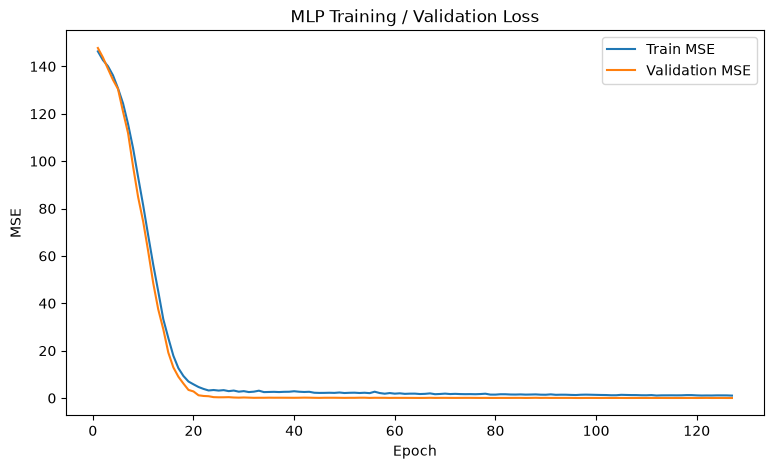

In [8]:

if history is not None:
    plt.figure(figsize=(9, 5))
    plt.plot(
        history["epoch"],
        history["train_mse"],
        label="Train MSE"
    )
    plt.plot(
        history["epoch"],
        history["valid_mse"],
        label="Validation MSE"
    )
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("MLP Training / Validation Loss")
    plt.legend()
    plt.show()


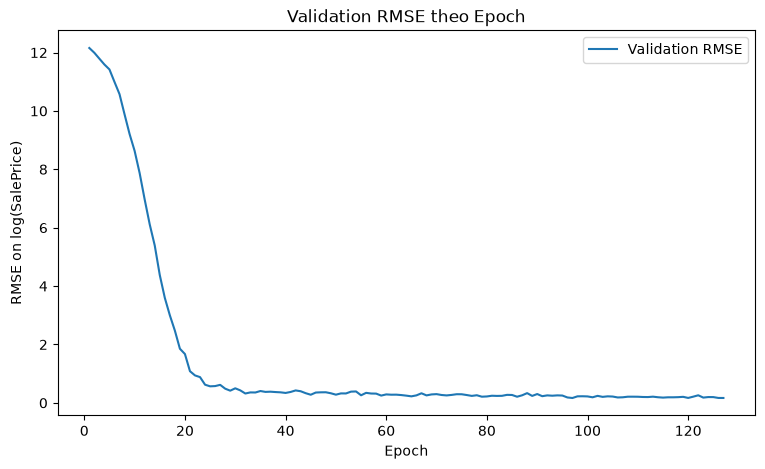

Best epoch: 97
Best validation RMSE: 0.166674216417342


In [9]:

if history is not None:
    plt.figure(figsize=(9, 5))
    plt.plot(
        history["epoch"],
        history["valid_rmse_log"],
        label="Validation RMSE"
    )
    plt.xlabel("Epoch")
    plt.ylabel("RMSE on log(SalePrice)")
    plt.title("Validation RMSE theo Epoch")
    plt.legend()
    plt.show()

    best_row = history.loc[
        history["valid_rmse_log"].idxmin()
    ]

    print("Best epoch:", int(best_row["epoch"]))
    print(
        "Best validation RMSE:",
        float(best_row["valid_rmse_log"])
    )


## 6. Đánh giá Hold-out Validation

Trong `train_mlp.py`, dữ liệu được chia:

```text
80% Training
20% Hold-out Validation
```

MLP được train trên 80%, còn 20% được dùng để theo dõi RMSE và early stopping.

Target được biến đổi:

```python
y_log = np.log1p(SalePrice)
```

Do đó RMSE được tính trên `log1p(SalePrice)`.


In [10]:

if metadata is not None:
    print(
        "Best hold-out RMSE on log(SalePrice):",
        metadata.get("best_valid_rmse_log")
    )
else:
    print("Chưa có metadata để đọc RMSE.")


Best hold-out RMSE on log(SalePrice): 0.166674216417342


## 7. Dự đoán trên `test.csv`

Sau khi train, chạy:

```powershell
python src/mlp/predict_mlp.py
```

sẽ tạo:

```text
submissions/submission_mlp.csv
```


In [11]:

submission_path = SUBMISSIONS_DIR / "submission_mlp.csv"

if submission_path.exists():
    submission_mlp = pd.read_csv(submission_path)

    print("Submission shape:", submission_mlp.shape)
    display(submission_mlp.head(10))

    print("\nPrediction statistics:")
    display(submission_mlp["SalePrice"].describe())
else:
    submission_mlp = None
    print("Chưa có submission_mlp.csv")
    print("Hãy chạy: python src/mlp/predict_mlp.py")


Submission shape: (1459, 2)


,Id,SalePrice
0,1461,116492.780
1,1462,135544.080
2,1463,188746.380
3,1464,180123.950
4,1465,180249.230
5,1466,183579.600
6,1467,178380.800
7,1468,176760.170
8,1469,177544.770
9,1470,129762.516



Prediction statistics:


count      1459.000000
mean     170355.884929
std       69426.809703
min       53530.945000
25%      120847.955000
50%      156143.500000
75%      197124.645000
max      472393.560000
Name: SalePrice, dtype: float64

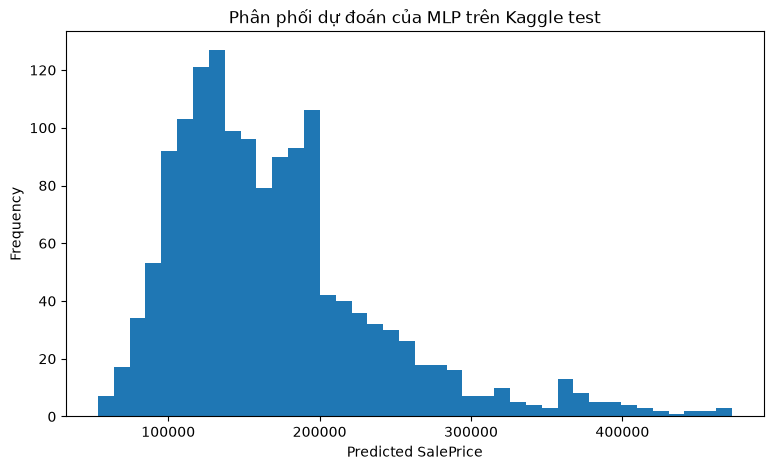

In [12]:

if submission_mlp is not None:
    plt.figure(figsize=(9, 5))
    plt.hist(
        submission_mlp["SalePrice"],
        bins=40
    )
    plt.xlabel("Predicted SalePrice")
    plt.ylabel("Frequency")
    plt.title("Phân phối dự đoán của MLP trên Kaggle test")
    plt.show()


## 8. So sánh MLP với mô hình sklearn

Phần này đọc `best_config.txt` của sklearn nếu file tồn tại.

Lưu ý:

- sklearn hiện được chọn dựa trên Cross-Validation.
- MLP hiện được đánh giá chủ yếu bằng hold-out validation.


In [13]:

sk_config_path = SKLEARN_MODEL_DIR / "best_config.txt"

sklearn_info = {}

if sk_config_path.exists():
    text = sk_config_path.read_text(encoding="utf-8")

    print("Best sklearn configuration:")
    print(text)

    for line in text.splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            sklearn_info[key.strip()] = value.strip()
else:
    print("Chưa có best_config.txt của sklearn.")


Best sklearn configuration:
Model: GradientBoosting
Feature Engineering: True
k: all
CV RMSE: 0.12566
Hold-out RMSE: 0.13731



In [14]:

rows = []

if sklearn_info:
    rows.append({
        "Model": sklearn_info.get("Model", "Best sklearn"),
        "Evaluation": "Hold-out / CV",
        "RMSE_log": sklearn_info.get(
            "Hold-out RMSE",
            sklearn_info.get("CV RMSE", "N/A")
        )
    })

if metadata is not None:
    rows.append({
        "Model": "PyTorch MLP",
        "Evaluation": "Hold-out",
        "RMSE_log": metadata.get(
            "best_valid_rmse_log",
            "N/A"
        )
    })

if rows:
    display(pd.DataFrame(rows))
else:
    print("Chưa đủ kết quả để so sánh.")


,Model,Evaluation,RMSE_log
0,GradientBoosting,Hold-out / CV,0.13731
1,PyTorch MLP,Hold-out,0.166674


## 9. Nhận xét


### Mô hình

MLP được xây dựng bằng PyTorch với nhiều hidden layer. Các hidden layer sử dụng `ReLU`, `BatchNorm1d` và `Dropout`. Output layer có một neuron để dự đoán `log1p(SalePrice)`.

### Dữ liệu đầu vào

MLP sử dụng cùng quy trình xử lý đặc trưng với nhánh sklearn:

- xử lý missing values,
- feature engineering,
- scaling numerical features,
- one-hot encoding categorical features,
- feature selection bằng `SelectKBest`.

### Quá trình huấn luyện

Mô hình được tối ưu bằng Adam và MSE Loss. Early stopping được sử dụng để dừng huấn luyện khi validation RMSE không còn cải thiện trong một số epoch liên tiếp.


